In [1]:
from pathlib import Path
import pandas as pd 
import numpy as np
from tqdm.auto import tqdm
import plotly.express as px
from plotly import graph_objects as go
tqdm.pandas()
from exports_utils import load_seedtest

root = Path('/data/data/malpolon/xgb/')
inputs_path = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/')
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')

In [6]:
fulldf = pd.read_csv(inputs_path / 'database_common.csv', index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})
species = list(fulldf.columns[-818:-1])
groundtruth = fulldf[species]

In [2]:
# Checkpoints

ind_cp_pa = '42_ind_pa_seedtest-2026-03-12_17-19'
td_cp_pa = '42_td_pa_seedtest-2026-03-11_14-31'

ind_cp_reg = '42_ind_reg_seedtest-2026-03-13_00-38'
td_cp_reg = '42_td_reg_seedtest-2026-03-12_10-21'

ind_cp_eco = '42_ind_eco_seedtest-2026-03-10_17-43'
td_cp_eco = '42_td_eco_seedtest-2026-03-10_14-13'

## P-A

#### Species F1

In [3]:
xgb_mean, xgb_ci = load_seedtest(output_path.parent / 'xgb', 'pa')
ind_mean, ind_ci = load_seedtest(output_path, ind_cp_pa)
td_mean, td_ci = load_seedtest(output_path, td_cp_pa)

In [4]:
scores = [xgb_mean, ind_mean, td_mean]
errors = [xgb_ci, ind_ci, td_ci]
names = ['XGBoost', 'Deep-SDM', 'Transductive']

In [5]:
fig = go.Figure()

colors = px.colors.qualitative.Pastel

# CI band — upper and lower as a filled trace

for i, n in enumerate(names):

    if errors[i] is not None:

        fig.add_trace(go.Scatter(
            x=np.concatenate([np.arange(400), np.arange(400)[::-1]]),
            y=np.concatenate([scores[i] + errors[i], (scores[i] - errors[i])[::-1]]),
            fill='toself',
            fillcolor=colors[i % len(colors)].replace('rgb(', 'rgba(').replace(')', ', 0.4)'),
            line=dict(color='rgba(255,255,255,0)'),  # no border line
            name='95% CI',
        ))

    # Mean curve (on top)
    fig.add_trace(go.Scatter(
        x=np.arange(400), y=np.array(scores[i]),
        mode='lines',
        line=dict(color=colors[i % len(colors)], width=3),
        name=n,
    ))

fig.update_layout(
    template='simple_white',
    width=1200, height=800,
    title='', #'Presence-absence classification',
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend_title_text='',
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)

fig.show()

[Text(0.5, 0, 'XGBoost F1'), Text(0, 0.5, 'Transductive F1')]

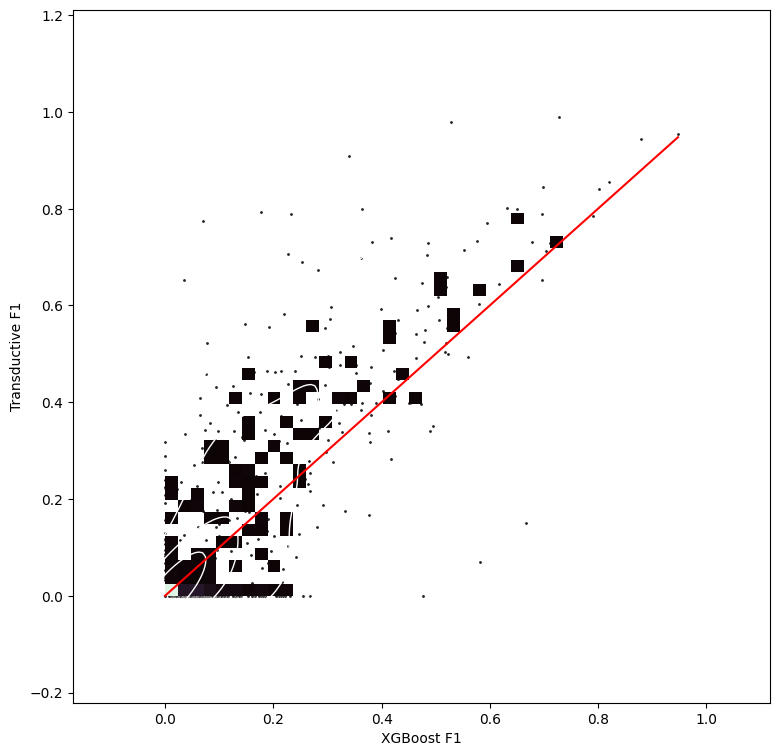

In [6]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = scores[names[0]].values, scores[names[2]].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel=names[0] + ' F1', ylabel=names[2] + ' F1')

#### Site F1

In [12]:
xgb_f1_site = pd.read_csv(output_path.parent / 'xgb' / 'pa' / 'f1_by_site.csv', index_col = 0)
td_f1_site = pd.read_csv(output_path / td_cp_pa / 'f1_by_site.csv', index_col = 0)

scores = pd.concat([xgb_f1_site['mean'], td_f1_site['mean']], axis=1)
scores.columns = ['XGB', 'TD']

In [32]:
sites = fulldf[['site_code', 'latitude', 'longitude']].where(fulldf['subset'] == 'test').dropna().drop_duplicates('site_code')
sites.index = sites['site_code']
sites

,site_code,latitude,longitude
site_code,,,
BUN-S1,BUN-S1,-38.68,145.61
BUN-S10,BUN-S10,-38.68,145.65
BUN-S11,BUN-S11,-38.67,145.69
BUN-S2,BUN-S2,-38.68,145.62
BUN-S3,BUN-S3,-38.68,145.65
...,...,...,...
WP-S5,WP-S5,-39.02,146.28
WP-S6,WP-S6,-39.04,146.30
WP-S7,WP-S7,-39.05,146.32


In [33]:
import plotly.express as px

meta = pd.read_csv(inputs_path / 'database_common_metadata.csv')
sites = fulldf[['site_code', 'latitude', 'longitude']].where(fulldf['subset'] == 'test').dropna().drop_duplicates('site_code')
sites.index = sites['site_code']
sites['delta'] = (scores['TD'] - scores['XGB']) #/ (scores['XGB']+1e-6)

fig = px.scatter_map(sites, lat='latitude',lon='longitude', color='delta', height = 1100, width = 1200,
                     center={'lat':-28, 'lon':133}, zoom=4, opacity=0.5,
                     color_continuous_midpoint=0,
                     color_continuous_scale=px.colors.sequential.RdBu, map_style='dark')

fig.update_traces(marker=dict(size=20))
fig.show()

In [34]:
(sites['delta'] / (scores['XGB']+1e-6)).describe()

count    412.000000
mean       0.242027
std        0.373990
min       -0.960104
25%        0.060404
50%        0.214892
75%        0.415689
max        3.805978
dtype: float64

/data/venvs/malp/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/venvs/malp/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/venvs/malp/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/venvs/malp/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN befo

[Text(0.5, 0, 'XGB F1'), Text(0, 0.5, 'TD F1')]

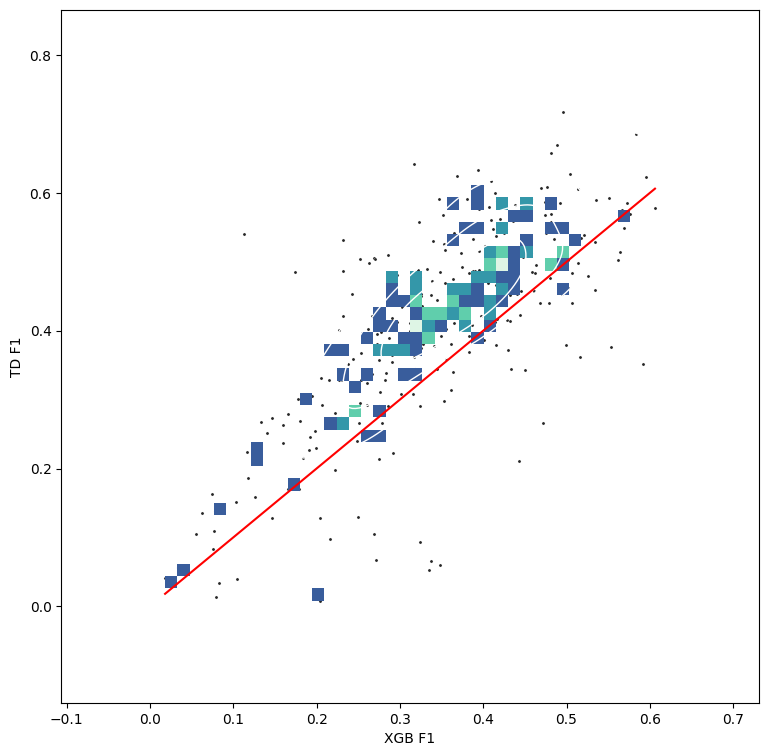

In [35]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = scores['XGB'].values, scores['TD'].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel='XGB F1', ylabel='TD F1')

## Reg

In [ ]:
xgb_mean, xgb_ci = load_seedtest(output_path.parent / 'xgb', 'reg')
ind_mean, ind_ci = load_seedtest(output_path, ind_cp_reg)
td_mean, td_ci = load_seedtest(output_path, td_cp_reg)

In [7]:
scores = [xgb_mean, ind_mean, td_mean]
errors = [xgb_ci, ind_ci, td_ci]
names = ['XGBoost', 'Deep-SDM', 'Transductive']

In [8]:
fig = go.Figure()

colors = px.colors.qualitative.Pastel

# CI band — upper and lower as a filled trace

for i, n in enumerate(names):

    if errors[i] is not None:

        fig.add_trace(go.Scatter(
            x=np.concatenate([np.arange(400), np.arange(400)[::-1]]),
            y=np.concatenate([scores[i] + errors[i], (scores[i] - errors[i])[::-1]]),
            fill='toself',
            fillcolor=colors[i % len(colors)].replace('rgb(', 'rgba(').replace(')', ', 0.4)'),
            line=dict(color='rgba(255,255,255,0)'),  # no border line
            name='95% CI',
        ))

    # Mean curve (on top)
    fig.add_trace(go.Scatter(
        x=np.arange(400), y=np.array(scores[i]),
        mode='lines',
        line=dict(color=colors[i % len(colors)], width=3),
        name=n,
    ))

fig.update_layout(
    template='simple_white',
    width=1200, height=800,
    title='', #'Presence-absence classification',
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend_title_text='',
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)

fig.show()

In [16]:
scores['delta'] = (scores['Transductive'] - scores['XGBoost']) / (scores['XGBoost']+1e-6)
scores['delta'].describe()

count     782.000000
mean       -1.805902
std        93.219415
min     -1988.800826
25%        -0.469179
50%         0.327894
75%         1.761176
max      1516.739267
Name: delta, dtype: float64

## Traits based

#### Load traits

In [7]:
traits = pd.read_csv('/data/data/RLS/traits.csv', index_col=0)

troph_level_dict = {s: traits['Troph'].get(s, np.nan) for s in species}
troph_level = pd.Series(troph_level_dict, index = species, name = 'troph_level')

uicnL_status_dict = {s: traits['IUCN_inferred_Loiseau23'].get(s, 'No Status') for s in species}
uicnL_status = pd.Series(uicnL_status_dict, index = species, name = 'uicnL_status')
uicnL_threatened = pd.Series([(uicnL_status_dict[s] == 'Threatened')*1 for s in species], index = species, name = 'Threatened')

uicn_species = list(uicnL_threatened[uicnL_threatened == 1].index)

#### Load scores to compare

In [25]:
# P-A

xgb_mean, xgb_ci = load_seedtest(output_path.parent / 'xgb', 'pa', reindex = False)
ind_mean, ind_ci = load_seedtest(output_path, ind_cp_pa, reindex = False)
td_mean, td_ci = load_seedtest(output_path, td_cp_pa, reindex = False)

scores = pd.concat([xgb_mean, td_mean], axis = 1)
names = ['XGB', 'Transductive']

In [13]:
td_mean

Notolabrus parilus              0.983573
Parma mccullochi                0.956927
Coris auricularis               0.975964
Notolabrus tetricus             0.964354
Notolabrus gymnogenis           0.936658
                                  ...   
Heterodontus portusjacksoni     0.000000
Heteroscarus acroptilus         0.019040
Hippocampus abdominalis         0.000000
Macropharyngodon negrosensis    0.000000
Hypoplectrodes nigroruber       0.000000
Length: 817, dtype: float64

In [29]:
# # Reg

xgb_mean, xgb_ci = load_seedtest(output_path.parent / 'xgb', 'reg', reindex = False)
ind_mean, ind_ci = load_seedtest(output_path, ind_cp_reg, reindex = False)
td_mean, td_ci = load_seedtest(output_path, td_cp_reg, reindex = False)

scores = pd.concat([xgb_mean, td_mean], axis = 1)
names = ['XGB', 'Transductive']

In [34]:
scores.sort_values(by='progress', ascending=False)

,XGB,Transductive,progress_perc,progress,max,uicnL_status,troph_level
Anampses lennardi,-0.640000,1.000000,-2.562504,1.640000,1.000000,Non Threatened,3.50
Chaetodon reticulatus,-0.633759,0.520239,-1.820881,1.153997,0.520239,Non Threatened,2.63
Ecsenius fourmanoiri,-0.100000,1.000000,-11.000110,1.100000,1.000000,Non Threatened,2.00
Neosebastes scorpaenoides,-0.748748,0.216639,-1.289336,0.965387,0.216639,Non Threatened,3.79
Crossosalarias macrospilus,-0.270774,0.570593,-3.107282,0.841367,0.570593,Non Threatened,2.00
...,...,...,...,...,...,...,...
Pomacentrus nigromanus,-0.100000,NaN,NaN,NaN,-0.100000,Non Threatened,3.23
Pseudocaranx sp. [dentex],-0.100000,NaN,NaN,NaN,-0.100000,No Status,NaN
Scorpaena cardinalis,-0.100000,NaN,NaN,NaN,-0.100000,Non Threatened,3.52
Stanulus talboti,-0.100000,NaN,NaN,NaN,-0.100000,Non Threatened,2.00


In [30]:
# Calculate progress


scores.columns = names
scores['progress_perc'] = (scores[names[1]] - scores[names[0]]) / (scores[names[0]] + 1e-6)
scores['progress'] = (scores[names[1]] - scores[names[0]]) 
scores['max'] = scores[names].max(axis=1)


# Add traits
scores['uicnL_status'] = uicnL_status.loc[scores.index]
scores['troph_level'] = troph_level.loc[scores.index]

relevant_scores = scores.loc[scores['max'] > 0.2].copy()

<Axes: >

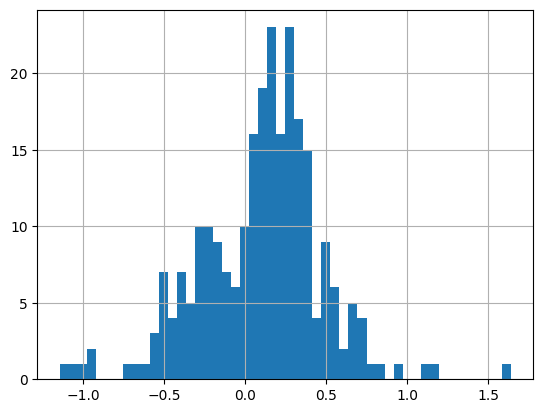

In [31]:
relevant_scores['progress'].hist(bins = 50)

#### Plot performance increase vs traits

In [35]:


fig = px.violin(relevant_scores, x="uicnL_status", y="progress", points = 'all', color = "uicnL_status",
                color_discrete_sequence= px.colors.qualitative.Pastel, box = True)


fig.update_layout(
    template='simple_white',
    width = 800, height=800,
    yaxis_title='Pearson delta',
    xaxis_title='',
    font=dict(size=20),
    showlegend=False)
    

fig.add_shape(type="line",
    xref="paper",
    x0=0, y0=0,
    x1=1, y1=0,
    line=dict(
        color="black",
        width=1,
    ))

fig.show()

In [17]:
relevant_scores = scores.loc[scores['max'] > 0.2].copy()

print(relevant_scores.groupby('uicnL_status')['progress_perc'].describe()['50%'])
print(relevant_scores['progress_perc'].describe()['50%'])

uicnL_status
No Status        -0.106985
Non Threatened    0.206182
Threatened        0.661844
Name: 50%, dtype: float64
0.22301199573716848


In [50]:
scores.sort_values(by='Transductive', ascending=False)

,XGB,Transductive,progress_perc,progress,max,uicnL_status,troph_level
Notolabrus gymnogenis,0.417212,0.651736,0.562119,0.234523,0.651736,Non Threatened,3.50
Chaetodon lunulatus,0.345173,0.534252,0.547780,0.189079,0.534252,Non Threatened,3.34
Halichoeres melanurus,0.361370,0.519718,0.438185,0.158348,0.519718,Non Threatened,2.90
Ophthalmolepis lineolatus,0.415375,0.518854,0.249121,0.103479,0.518854,Non Threatened,3.50
Ctenochaetus striatus,0.466384,0.507201,0.087519,0.040817,0.507201,Non Threatened,2.00
...,...,...,...,...,...,...,...
Pomacanthus navarchus,-0.100000,NaN,NaN,NaN,-0.100000,Non Threatened,2.66
Pseudocaranx sp. [dentex],-0.100000,NaN,NaN,NaN,-0.100000,No Status,NaN
Scorpaena cardinalis,-0.100000,NaN,NaN,NaN,-0.100000,Non Threatened,3.52
Stanulus talboti,-0.100000,NaN,NaN,NaN,-0.100000,Non Threatened,2.00


## Eco indicators

In [8]:
xgb_mean, xgb_ci = load_seedtest('/data/data/malpolon/xgb/', 'eco')
ind_mean, ind_ci = load_seedtest(output_path, ind_cp_eco)
td_mean, td_ci = load_seedtest(output_path, td_cp_eco)

tdstacked_r2 = pd.read_csv(output_path / td_cp_pa / 'eco_indic_corr.csv', index_col=0)

In [9]:
scores = pd.concat([xgb_mean, ind_mean, td_mean, tdstacked_r2["mean"]], axis = 1)
errors = [xgb_ci, ind_ci, td_ci, None]
names = ['XGBoost', 'Deep-SDM', 'Transductive (direct)', 'Transductive (stacked)']
scores.columns = names

In [10]:
fig = go.Figure()

colors = px.colors.qualitative.Pastel

for i, n in enumerate(names[:-1]):
    fig.add_trace(go.Bar(
        name=n,
        x=scores.index, y=scores.iloc[:,i],
        error_y=dict(type='data', array=errors[i]),
        marker_color=colors[i % len(colors)],
    ))

fig.add_trace(go.Bar(
    name=names[-1],
    x=tdstacked_r2.index, y=scores.iloc[:,-1],
    error_y=dict(type='data',
                 symmetric=False,
                 array=tdstacked_r2['max'] - scores.iloc[:,-1],
                 arrayminus=scores.iloc[:,-1] -tdstacked_r2['min']),
    marker_color=colors[len(names) -1 % len(colors)],
    ))

fig.update_layout(barmode='group',
                  width = 800, height=800,
                  template = 'simple_white',
                  title='',
                  xaxis_title='',
                  yaxis_title='Pearson R',
                  font=dict(size=20),
                  legend_title_text='',
                  legend=dict(yanchor="top",
                              y=0.99,
                              xanchor="center",
                              x=0.5),
)

fig.show()


# fig = px.bar(data, x=data['species'], y='pearsonr', color='model', template = 'simple_white', barmode='group',
#            width = 800, height=800,
#            )


## Any 2

#### 1v1 BlandAltman

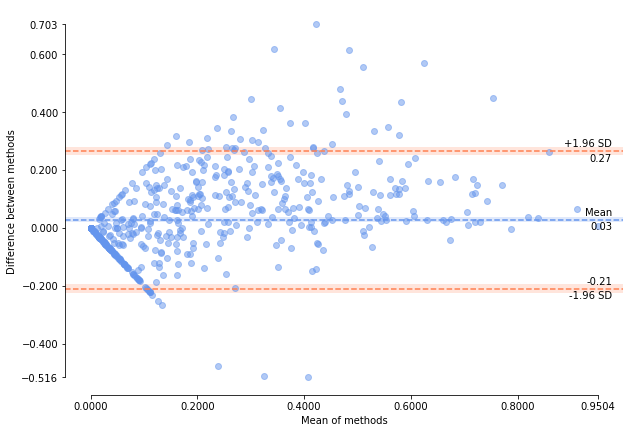

In [31]:
import pyCompare

pyCompare.blandAltman(scores[names[2]].values,scores[names[0]].values)

#### 1v1 Scatter plot

[Text(0.5, 0, 'XGBoost F1'), Text(0, 0.5, 'Transductive F1')]

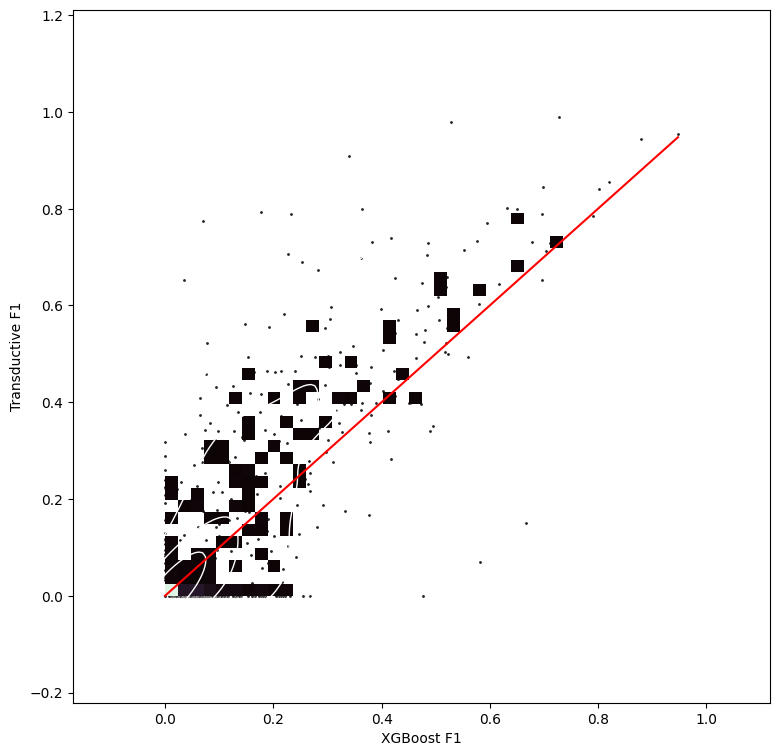

In [30]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = scores[names[0]].values, scores[names[2]].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel=names[0] + ' F1', ylabel=names[2] + ' F1')

#### 1v1 arrow scatter

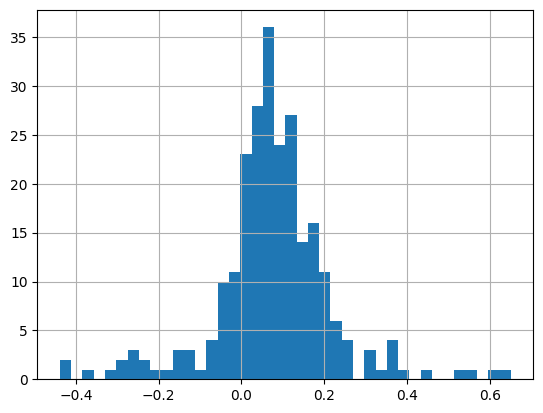

In [18]:
(relevant_scores['Transductive'] - relevant_scores['XGB']).hist(bins=40)

relevant_scores.sort_values(by='XGB', ascending=False, inplace=True)
relevant_scores['x'] = np.arange(len(relevant_scores))

In [19]:
# Example data
x = relevant_scores['x']
y1 = relevant_scores['XGB']
y2 = relevant_scores['Transductive']
hover_text = relevant_scores.index.to_list()

# Create the figure
fig = go.Figure()

# Add the two series as scatter plots
fig.add_trace(go.Scatter(
    x=x, y=y1,
    mode='markers',
    marker=dict(color=px.colors.qualitative.Pastel[0], size=10),
    name='XGBoost',
    hovertext=hover_text,
    hoverinfo='text'
))

fig.add_trace(go.Scatter(
    x=x, y=y2,
    mode='markers',
    marker=dict(color=px.colors.qualitative.Pastel[3], size=10),
    name='Transductive',
    hovertext=hover_text,
    hoverinfo='text'
))

# Add arrows for the differences
for i in range(len(x)):
    fig.add_annotation(
        ax=x[i], ay=y1[i],
        axref='x', ayref='y',
        x=x[i], y=y2[i],
        xref='x', yref='y',
        showarrow=True,
        arrowhead=1,
        arrowsize=1.5,
        arrowcolor=px.colors.qualitative.Pastel1[1],
        arrowwidth=1.5,
    )


fig.update_layout(
    template='simple_white',
    width = 1200, height=800,
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)


/tmp/ipykernel_108767/759123879.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax=x[i], ay=y1[i],
/tmp/ipykernel_108767/759123879.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x=x[i], y=y2[i],
